# Notebook 00 — Descarga y exploración inicial de datos


In [70]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings("ignore")

# 1. Extraccción Tolima

## 1.1. Precipitación

### Consolidación Base Precipitación Tolima

In [71]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

ruta = Path("../datos/raw/ideam/Tolima_Precipitación")
carpeta=ruta

archivos = list(carpeta.glob("*.xlsx"))

base = None

for archivo in archivos:
    print("Procesando:", archivo.name)

    nombre_estacion = pd.read_excel(
        archivo,
        header=None,
        nrows=2
    ).iloc[1, 1]

    if pd.isna(nombre_estacion):
        nombre_estacion = archivo.stem

    nombre_estacion = str(nombre_estacion)

    df = pd.read_excel(
        archivo,
        sheet_name="Datos",
        header=None,
        skiprows=7
    )

    df = df[[0, 2]]
    df.columns = ["fecha", nombre_estacion]

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df[nombre_estacion] = (
        df[nombre_estacion]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )

    df[nombre_estacion] = pd.to_numeric(
        df[nombre_estacion],
        errors="coerce"
    )

    df = df.dropna(subset=["fecha"])

    if base is None:
        base = df
    else:
        base = pd.merge(
            base,
            df,
            on="fecha",
            how="outer"
        )

base = base.sort_values("fecha").reset_index(drop=True)

#Dato solo desde 2010
base = base[
    base["fecha"] >= pd.Timestamp("2010-01-01")
].reset_index(drop=True)

original = base.copy()

print("Base consolidada")
print(
    "Fechas:",
    base["fecha"].min(),
    "hasta",
    base["fecha"].max()
)

original = base.copy()

print("Base consolidada")

Procesando: 21135020.xlsx
Procesando: 21135030.xlsx
Procesando: 21185030.xlsx
Procesando: 21185080.xlsx
Procesando: 21215080.xlsx
Procesando: 21245040.xlsx
Procesando: 21245140.xlsx
Procesando: 22055020.xlsx
Procesando: 22065040.xlsx
Procesando: 23025040.xlsx
Base consolidada
Fechas: 2010-01-01 00:00:00 hasta 2025-12-31 00:00:00
Base consolidada


### Prueba de estacionariedad y estacionalidad

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

resumen_pruebas = []

for columna in base.columns:

    if columna == "fecha":
        continue

    serie = base[["fecha", columna]].dropna()
    serie = serie.set_index("fecha")[columna]

    if len(serie) < 24:
        resumen_pruebas.append({
            "estacion": columna,
            "n_observaciones": len(serie),
            "ADF_p_value": np.nan,
            "es_estacionaria": "No evaluable",
            "observacion": "Muy pocos datos"
        })
        continue

    resultado_adf = adfuller(serie)

    p_value = resultado_adf[1]

    es_estacionaria = "Sí" if p_value < 0.05 else "No"

    resumen_pruebas.append({
        "estacion": columna,
        "n_observaciones": len(serie),
        "ADF_p_value": p_value,
        "es_estacionaria": es_estacionaria,
        "observacion": "Evaluada"
    })

resumen_pruebas = pd.DataFrame(resumen_pruebas)

resumen_pruebas

### ARIMA para vacios


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima

def imputar_arima(df, columna):

    datos = df[["fecha", columna]].copy()
    datos = datos.sort_values("fecha")
    datos = datos.set_index("fecha")

    y = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

    # Guardar ubicación de vacíos originales
    mask_na_original = y.isna()

    # Si hay pocos datos usar interpolación
    if y.notna().sum() < 30:

        y_final = (
            y.interpolate("linear")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            "Interpolación (pocos datos)"
        )

    # Interpolación temporal preliminar
    # necesaria para entrenar ARIMA
    y_temp = (
        y.interpolate("linear")
        .ffill()
        .bfill()
    )

    try:

        # Selección automática de p,d,q
        modelo_auto = auto_arima(
            y_temp,
            seasonal=False,
            d=0,   # ADF mostró estacionariedad
            trace=False,
            suppress_warnings=True
        )

        p,d,q = modelo_auto.order

        modelo = ARIMA(
            y_temp,
            order=(p,d,q)
        )

        ajuste = modelo.fit()

        predicciones = ajuste.predict(
            start=0,
            end=len(y_temp)-1
        )

        y_final = y.copy()

        # Solo reemplazar vacíos originales
        y_final.loc[
            mask_na_original
        ] = predicciones.loc[
            mask_na_original
        ]

        return (
            y_final.reset_index(drop=True),
            f"ARIMA{(p,d,q)}"
        )

    except Exception as e:

        y_final = (
            y.interpolate("linear")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            f"Interpolación por error: {e}"
        )

In [ ]:
def seleccionar_mejor_arima(serie):

    mejor_aic = np.inf
    mejor_orden = None

    ordenes = [
        (1, 0, 0),
        (0, 0, 1),
        (1, 0, 1),
        (2, 0, 0),
        (0, 0, 2),
        (2, 0, 1),
        (1, 0, 2)
    ]

    for orden in ordenes:

        try:
            modelo = ARIMA(
                serie,
                order=orden
            )

            resultado = modelo.fit(
                method_kwargs={"maxiter": 50}
            )

            if resultado.aic < mejor_aic:
                mejor_aic = resultado.aic
                mejor_orden = orden

        except:
            continue

    if mejor_orden is None:
        mejor_orden = (1, 0, 0)

    return mejor_orden

In [ ]:
def imputar_arima(df, columna):

    datos = df[["fecha", columna]].copy()
    datos = datos.sort_values("fecha")

    datos = datos.set_index("fecha")
    datos.index = pd.to_datetime(datos.index)

    y = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

    mask_na_original = y.isna()

    # Si hay pocos datos, usar interpolación temporal
    if y.notna().sum() < 30:

        y_final = (
            y
            .interpolate(method="time")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            "Interpolación temporal por pocos datos"
        )

    # Interpolación preliminar para que ARIMA pueda entrenarse
    y_temp = (
        y
        .interpolate(method="time")
        .ffill()
        .bfill()
    )

    try:
        orden = seleccionar_mejor_arima(y_temp)

        modelo = ARIMA(
            y_temp,
            order=orden
        )

        ajuste = modelo.fit(
            method_kwargs={"maxiter": 50}
        )

        predicciones = ajuste.predict(
            start=0,
            end=len(y_temp) - 1
        )

        y_final = y.copy()

        # Solo reemplaza los datos que originalmente estaban vacíos
        y_final.loc[mask_na_original] = predicciones.loc[mask_na_original]

        # Respaldo final: si queda algún vacío, se completa
        y_final = (
            y_final
            .interpolate(method="time")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            f"ARIMA{orden} + respaldo temporal"
        )

    except Exception as e:

        y_final = (
            y
            .interpolate(method="time")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            f"Interpolación temporal porque ARIMA falló: {e}"
        )

In [ ]:
completado = base.copy()

marca_imputacion = pd.DataFrame()
marca_imputacion["fecha"] = base["fecha"]

resumen_modelos = []

for columna in base.columns:

    if columna == "fecha":
        continue

    print("Imputando:", columna)

    marca_imputacion[columna] = base[columna].isna()

    serie_completa, metodo = imputar_arima(
        base,
        columna
    )

    completado[columna] = serie_completa

    resumen_modelos.append({
        "estacion": columna,
        "modelo_usado": metodo,
        "observaciones_originales": base[columna].notna().sum(),
        "valores_imputados": base[columna].isna().sum(),
        "porcentaje_imputado": round(
            100 * base[columna].isna().sum() / len(base),
            2
        ),
        "faltantes_finales": completado[columna].isna().sum()
    })

resumen_modelos = pd.DataFrame(resumen_modelos)

print("Imputación terminada")

Imputando: JABALCON [21135020]
Imputando: ANCHIQUE [21135030]
Imputando: GUAMO [21185030]
Imputando: VALLE DE SAN JUAN [21185080]
Imputando: CHICORAL [21215080]
Imputando: AEROPUERTO PERALES [21245040]
Imputando: SANTA ISABEL [21245140]
Imputando: MESA DE POLE [22055020]
Imputando: SAN ANTONIO QUINTA [22065040]
Imputando: ALBANIA - AUT [23025040]
Imputación terminada


In [ ]:
faltantes_finales = completado.isna().sum()

faltantes_finales

fecha                            0
JABALCON [21135020]              0
ANCHIQUE [21135030]              0
GUAMO [21185030]                 0
VALLE DE SAN JUAN [21185080]     0
CHICORAL [21215080]              0
AEROPUERTO PERALES [21245040]    0
SANTA ISABEL [21245140]          0
MESA DE POLE [22055020]          0
SAN ANTONIO QUINTA [22065040]    0
ALBANIA - AUT [23025040]         0
dtype: int64

In [ ]:
# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Tolima_Precipitación.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    completado.to_excel(
        writer,
        sheet_name="Completado",
        index=False
    )

    original.to_excel(
        writer,
        sheet_name="Original",
        index=False
    )

    marca_imputacion.to_excel(
        writer,
        sheet_name="Marca_imputacion",
        index=False
    )

    resumen_pruebas.to_excel(
        writer,
        sheet_name="Pruebas_ADF",
        index=False
    )

    resumen_modelos.to_excel(
        writer,
        sheet_name="Resumen_modelos",
        index=False
    )

print("Archivo creado: Tolima_Precipitación.xlsx")

Archivo creado: Tolima_Precipitación.xlsx


## 1.2. Temperatura máxima

### Consolidación Base Temperatura Máxima Tolima

In [ ]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

ruta = Path("../datos/raw/ideam/Tolima_TempMax")
carpeta = ruta

archivos = list(carpeta.glob("*.xlsx"))

base = None

for archivo in archivos:
    print("Procesando:", archivo.name)

    nombre_estacion = pd.read_excel(
        archivo,
        header=None,
        nrows=2
    ).iloc[1, 1]

    if pd.isna(nombre_estacion):
        nombre_estacion = archivo.stem

    nombre_estacion = str(nombre_estacion)

    df = pd.read_excel(
        archivo,
        sheet_name="Datos",
        header=None,
        skiprows=7
    )

    df = df[[0, 2]]
    df.columns = ["fecha", nombre_estacion]

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df[nombre_estacion] = (
        df[nombre_estacion]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )

    df[nombre_estacion] = pd.to_numeric(
        df[nombre_estacion],
        errors="coerce"
    )

    df = df.dropna(subset=["fecha"])

    if base is None:
        base = df
    else:
        base = pd.merge(
            base,
            df,
            on="fecha",
            how="outer"
        )

base = base.sort_values("fecha").reset_index(drop=True)

#Dato solo desde 2010
base = base[
    base["fecha"] >= pd.Timestamp("2010-01-01")
].reset_index(drop=True)

original = base.copy()

print("Base consolidada")
print(
    "Fechas:",
    base["fecha"].min(),
    "hasta",
    base["fecha"].max()
)

original = base.copy()

print("Base consolidada")

Procesando: 35095110.xlsx
Procesando: 35195030.xlsx
Procesando: 35215020.xlsx
Procesando: 35225030.xlsx
Procesando: 35235040.xlsx
Procesando: 35235050.xlsx
Procesando: 36015010.xlsx
Base consolidada
Fechas: 2010-01-01 00:00:00 hasta 2025-12-31 00:00:00
Base consolidada


### Prueba de estacionariedad y estacionalidad

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

resumen_pruebas = []

for columna in base.columns:

    if columna == "fecha":
        continue

    serie = base[["fecha", columna]].dropna()
    serie = serie.set_index("fecha")[columna]

    if len(serie) < 24:
        resumen_pruebas.append({
            "estacion": columna,
            "n_observaciones": len(serie),
            "ADF_p_value": np.nan,
            "es_estacionaria": "No evaluable",
            "observacion": "Muy pocos datos"
        })
        continue

    resultado_adf = adfuller(serie)

    p_value = resultado_adf[1]

    es_estacionaria = "Sí" if p_value < 0.05 else "No"

    resumen_pruebas.append({
        "estacion": columna,
        "n_observaciones": len(serie),
        "ADF_p_value": p_value,
        "es_estacionaria": es_estacionaria,
        "observacion": "Evaluada"
    })

resumen_pruebas = pd.DataFrame(resumen_pruebas)

resumen_pruebas

,estacion,n_observaciones,ADF_p_value,es_estacionaria,observacion
0,HUERTA LA GRANDE [35095110],5835,2.301163e-12,Sí,Evaluada
1,AGUAZUL [35195030],4382,8.399109e-12,Sí,Evaluada
2,AEROPUERTO YOPAL - AUT [35215020],5671,3.908391e-15,Sí,Evaluada
3,MODULOS - AUT [35225030],5650,1.108505e-12,Sí,Evaluada
4,TRINIDAD - AUT [35235040],5688,3.740628e-17,Sí,Evaluada
5,TAMARA - AUT [35235050],5816,5.729285e-10,Sí,Evaluada
6,PAZ DE ARIPORO [36015010],5483,1.650177e-13,Sí,Evaluada


### ARIMA para vacios


In [ ]:
completado = base.copy()

marca_imputacion = pd.DataFrame()
marca_imputacion["fecha"] = base["fecha"]

resumen_modelos = []

for columna in base.columns:

    if columna == "fecha":
        continue

    print("Imputando:", columna)

    marca_imputacion[columna] = base[columna].isna()

    serie_completa, metodo = imputar_arima(
        base,
        columna
    )

    completado[columna] = serie_completa

    resumen_modelos.append({
        "estacion": columna,
        "modelo_usado": metodo,
        "observaciones_originales": base[columna].notna().sum(),
        "valores_imputados": base[columna].isna().sum(),
        "porcentaje_imputado": round(
            100 * base[columna].isna().sum() / len(base),
            2
        ),
        "faltantes_finales": completado[columna].isna().sum()
    })

resumen_modelos = pd.DataFrame(resumen_modelos)

print("Imputación terminada")

Imputando: HUERTA LA GRANDE [35095110]
Imputando: AGUAZUL [35195030]
Imputando: AEROPUERTO YOPAL - AUT [35215020]
Imputando: MODULOS - AUT [35225030]
Imputando: TRINIDAD - AUT [35235040]
Imputando: TAMARA - AUT [35235050]
Imputando: PAZ DE ARIPORO [36015010]
Imputación terminada


In [ ]:
faltantes_finales = completado.isna().sum()

faltantes_finales

fecha                                0
HUERTA LA GRANDE [35095110]          0
AGUAZUL [35195030]                   0
AEROPUERTO YOPAL - AUT [35215020]    0
MODULOS - AUT [35225030]             0
TRINIDAD - AUT [35235040]            0
TAMARA - AUT [35235050]              0
PAZ DE ARIPORO [36015010]            0
dtype: int64

In [ ]:
# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Tolima_TempMax.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    completado.to_excel(
        writer,
        sheet_name="Completado",
        index=False
    )

    original.to_excel(
        writer,
        sheet_name="Original",
        index=False
    )

    marca_imputacion.to_excel(
        writer,
        sheet_name="Marca_imputacion",
        index=False
    )

    resumen_pruebas.to_excel(
        writer,
        sheet_name="Pruebas_ADF",
        index=False
    )

    resumen_modelos.to_excel(
        writer,
        sheet_name="Resumen_modelos",
        index=False
    )

print("Archivo creado: Tolima_TempMáx")

Archivo creado: Tolima_TempMáx


## 1.3. Temperatura mínima

### Consolidación Base Temperatura Mínima Tolima

In [ ]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

ruta = Path("../datos/raw/ideam/Tolima_TempMin")
carpeta = ruta

archivos = list(carpeta.glob("*.xlsx"))

base = None

for archivo in archivos:
    print("Procesando:", archivo.name)

    nombre_estacion = pd.read_excel(
        archivo,
        header=None,
        nrows=2
    ).iloc[1, 1]

    if pd.isna(nombre_estacion):
        nombre_estacion = archivo.stem

    nombre_estacion = str(nombre_estacion)

    df = pd.read_excel(
        archivo,
        sheet_name="Datos",
        header=None,
        skiprows=7
    )

    df = df[[0, 2]]
    df.columns = ["fecha", nombre_estacion]

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df[nombre_estacion] = (
        df[nombre_estacion]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )

    df[nombre_estacion] = pd.to_numeric(
        df[nombre_estacion],
        errors="coerce"
    )

    df = df.dropna(subset=["fecha"])

    if base is None:
        base = df
    else:
        base = pd.merge(
            base,
            df,
            on="fecha",
            how="outer"
        )

base = base.sort_values("fecha").reset_index(drop=True)

#Dato solo desde 2010
base = base[
    base["fecha"] >= pd.Timestamp("2010-01-01")
].reset_index(drop=True)

original = base.copy()

print("Base consolidada")
print(
    "Fechas:",
    base["fecha"].min(),
    "hasta",
    base["fecha"].max()
)

original = base.copy()

print("Base consolidada")

Procesando: 35095110.xlsx
Procesando: 35195030.xlsx
Procesando: 35215020.xlsx
Procesando: 35225030.xlsx
Procesando: 35235040.xlsx
Procesando: 35235050.xlsx
Procesando: 36015010.xlsx
Base consolidada
Fechas: 2010-01-01 00:00:00 hasta 2025-12-31 00:00:00
Base consolidada


### Prueba de estacionariedad y estacionalidad

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

resumen_pruebas = []

for columna in base.columns:

    if columna == "fecha":
        continue

    serie = base[["fecha", columna]].dropna()
    serie = serie.set_index("fecha")[columna]

    if len(serie) < 24:
        resumen_pruebas.append({
            "estacion": columna,
            "n_observaciones": len(serie),
            "ADF_p_value": np.nan,
            "es_estacionaria": "No evaluable",
            "observacion": "Muy pocos datos"
        })
        continue

    resultado_adf = adfuller(serie)

    p_value = resultado_adf[1]

    es_estacionaria = "Sí" if p_value < 0.05 else "No"

    resumen_pruebas.append({
        "estacion": columna,
        "n_observaciones": len(serie),
        "ADF_p_value": p_value,
        "es_estacionaria": es_estacionaria,
        "observacion": "Evaluada"
    })

resumen_pruebas = pd.DataFrame(resumen_pruebas)

resumen_pruebas

,estacion,n_observaciones,ADF_p_value,es_estacionaria,observacion
0,HUERTA LA GRANDE [35095110],5835,2.301163e-12,Sí,Evaluada
1,AGUAZUL [35195030],4382,8.399109e-12,Sí,Evaluada
2,AEROPUERTO YOPAL - AUT [35215020],5671,3.908391e-15,Sí,Evaluada
3,MODULOS - AUT [35225030],5650,1.108505e-12,Sí,Evaluada
4,TRINIDAD - AUT [35235040],5688,3.740628e-17,Sí,Evaluada
5,TAMARA - AUT [35235050],5816,5.729285e-10,Sí,Evaluada
6,PAZ DE ARIPORO [36015010],5483,1.650177e-13,Sí,Evaluada


### ARIMA para vacios


In [ ]:
completado = base.copy()

marca_imputacion = pd.DataFrame()
marca_imputacion["fecha"] = base["fecha"]

resumen_modelos = []

for columna in base.columns:

    if columna == "fecha":
        continue

    print("Imputando:", columna)

    marca_imputacion[columna] = base[columna].isna()

    serie_completa, metodo = imputar_arima(
        base,
        columna
    )

    completado[columna] = serie_completa

    resumen_modelos.append({
        "estacion": columna,
        "modelo_usado": metodo,
        "observaciones_originales": base[columna].notna().sum(),
        "valores_imputados": base[columna].isna().sum(),
        "porcentaje_imputado": round(
            100 * base[columna].isna().sum() / len(base),
            2
        ),
        "faltantes_finales": completado[columna].isna().sum()
    })

resumen_modelos = pd.DataFrame(resumen_modelos)

print("Imputación terminada")

Imputando: HUERTA LA GRANDE [35095110]
Imputando: AGUAZUL [35195030]
Imputando: AEROPUERTO YOPAL - AUT [35215020]
Imputando: MODULOS - AUT [35225030]
Imputando: TRINIDAD - AUT [35235040]
Imputando: TAMARA - AUT [35235050]
Imputando: PAZ DE ARIPORO [36015010]
Imputación terminada


In [ ]:
faltantes_finales = completado.isna().sum()

faltantes_finales

fecha                                0
HUERTA LA GRANDE [35095110]          0
AGUAZUL [35195030]                   0
AEROPUERTO YOPAL - AUT [35215020]    0
MODULOS - AUT [35225030]             0
TRINIDAD - AUT [35235040]            0
TAMARA - AUT [35235050]              0
PAZ DE ARIPORO [36015010]            0
dtype: int64

In [ ]:
# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Tolima_TempMin.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    completado.to_excel(
        writer,
        sheet_name="Completado",
        index=False
    )

    original.to_excel(
        writer,
        sheet_name="Original",
        index=False
    )

    marca_imputacion.to_excel(
        writer,
        sheet_name="Marca_imputacion",
        index=False
    )

    resumen_pruebas.to_excel(
        writer,
        sheet_name="Pruebas_ADF",
        index=False
    )

    resumen_modelos.to_excel(
        writer,
        sheet_name="Resumen_modelos",
        index=False
    )

print("Archivo creado: Tolima_TempMin.xlsx")

Archivo creado: Tolima_TempMin.xlsx


# 2. Extraccción Casanare

## 2.1. Precipitación

### Consolidación Base Precipitación Casanare

In [ ]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

ruta = Path("../datos/raw/ideam/Casanare_Precipitación")
carpeta=ruta

archivos = list(carpeta.glob("*.xlsx"))

base = None

for archivo in archivos:
    print("Procesando:", archivo.name)

    nombre_estacion = pd.read_excel(
        archivo,
        header=None,
        nrows=2
    ).iloc[1, 1]

    if pd.isna(nombre_estacion):
        nombre_estacion = archivo.stem

    nombre_estacion = str(nombre_estacion)

    df = pd.read_excel(
        archivo,
        sheet_name="Datos",
        header=None,
        skiprows=7
    )

    df = df[[0, 2]]
    df.columns = ["fecha", nombre_estacion]

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df[nombre_estacion] = (
        df[nombre_estacion]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )

    df[nombre_estacion] = pd.to_numeric(
        df[nombre_estacion],
        errors="coerce"
    )

    df = df.dropna(subset=["fecha"])

    if base is None:
        base = df
    else:
        base = pd.merge(
            base,
            df,
            on="fecha",
            how="outer"
        )

base = base.sort_values("fecha").reset_index(drop=True)

#Dato solo desde 2010
base = base[
    base["fecha"] >= pd.Timestamp("2010-01-01")
].reset_index(drop=True)

original = base.copy()

print("Base consolidada")
print(
    "Fechas:",
    base["fecha"].min(),
    "hasta",
    base["fecha"].max()
)

original = base.copy()

print("Base consolidada")

Procesando: 35095110.xlsx
Procesando: 35195030.xlsx
Procesando: 35215020.xlsx
Procesando: 35225030.xlsx
Procesando: 35235040.xlsx
Procesando: 35235050.xlsx
Procesando: 36015010.xlsx
Base consolidada
Fechas: 2010-01-01 00:00:00 hasta 2025-12-31 00:00:00
Base consolidada


### Prueba de estacionariedad y estacionalidad

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

resumen_pruebas = []

for columna in base.columns:

    if columna == "fecha":
        continue

    serie = base[["fecha", columna]].dropna()
    serie = serie.set_index("fecha")[columna]

    if len(serie) < 24:
        resumen_pruebas.append({
            "estacion": columna,
            "n_observaciones": len(serie),
            "ADF_p_value": np.nan,
            "es_estacionaria": "No evaluable",
            "observacion": "Muy pocos datos"
        })
        continue

    resultado_adf = adfuller(serie)

    p_value = resultado_adf[1]

    es_estacionaria = "Sí" if p_value < 0.05 else "No"

    resumen_pruebas.append({
        "estacion": columna,
        "n_observaciones": len(serie),
        "ADF_p_value": p_value,
        "es_estacionaria": es_estacionaria,
        "observacion": "Evaluada"
    })

resumen_pruebas = pd.DataFrame(resumen_pruebas)

resumen_pruebas

,estacion,n_observaciones,ADF_p_value,es_estacionaria,observacion
0,HUERTA LA GRANDE [35095110],5835,2.301163e-12,Sí,Evaluada
1,AGUAZUL [35195030],4382,8.399109e-12,Sí,Evaluada
2,AEROPUERTO YOPAL - AUT [35215020],5671,3.908391e-15,Sí,Evaluada
3,MODULOS - AUT [35225030],5650,1.108505e-12,Sí,Evaluada
4,TRINIDAD - AUT [35235040],5688,3.740628e-17,Sí,Evaluada
5,TAMARA - AUT [35235050],5816,5.729285e-10,Sí,Evaluada
6,PAZ DE ARIPORO [36015010],5483,1.650177e-13,Sí,Evaluada


### ARIMA para vacios


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima

def imputar_arima(df, columna):

    datos = df[["fecha", columna]].copy()
    datos = datos.sort_values("fecha")
    datos = datos.set_index("fecha")

    y = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

    # Guardar ubicación de vacíos originales
    mask_na_original = y.isna()

    # Si hay pocos datos usar interpolación
    if y.notna().sum() < 30:

        y_final = (
            y.interpolate("linear")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            "Interpolación (pocos datos)"
        )

    # Interpolación temporal preliminar
    # necesaria para entrenar ARIMA
    y_temp = (
        y.interpolate("linear")
        .ffill()
        .bfill()
    )

    try:

        # Selección automática de p,d,q
        modelo_auto = auto_arima(
            y_temp,
            seasonal=False,
            d=0,   # ADF mostró estacionariedad
            trace=False,
            suppress_warnings=True
        )

        p,d,q = modelo_auto.order

        modelo = ARIMA(
            y_temp,
            order=(p,d,q)
        )

        ajuste = modelo.fit()

        predicciones = ajuste.predict(
            start=0,
            end=len(y_temp)-1
        )

        y_final = y.copy()

        # Solo reemplazar vacíos originales
        y_final.loc[
            mask_na_original
        ] = predicciones.loc[
            mask_na_original
        ]

        return (
            y_final.reset_index(drop=True),
            f"ARIMA{(p,d,q)}"
        )

    except Exception as e:

        y_final = (
            y.interpolate("linear")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            f"Interpolación por error: {e}"
        )

In [ ]:
def seleccionar_mejor_arima(serie):

    mejor_aic = np.inf
    mejor_orden = None

    ordenes = [
        (1, 0, 0),
        (0, 0, 1),
        (1, 0, 1),
        (2, 0, 0),
        (0, 0, 2),
        (2, 0, 1),
        (1, 0, 2)
    ]

    for orden in ordenes:

        try:
            modelo = ARIMA(
                serie,
                order=orden
            )

            resultado = modelo.fit(
                method_kwargs={"maxiter": 50}
            )

            if resultado.aic < mejor_aic:
                mejor_aic = resultado.aic
                mejor_orden = orden

        except:
            continue

    if mejor_orden is None:
        mejor_orden = (1, 0, 0)

    return mejor_orden

In [ ]:
def imputar_arima(df, columna):

    datos = df[["fecha", columna]].copy()
    datos = datos.sort_values("fecha")

    datos = datos.set_index("fecha")
    datos.index = pd.to_datetime(datos.index)

    y = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

    mask_na_original = y.isna()

    # Si hay pocos datos, usar interpolación temporal
    if y.notna().sum() < 30:

        y_final = (
            y
            .interpolate(method="time")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            "Interpolación temporal por pocos datos"
        )

    # Interpolación preliminar para que ARIMA pueda entrenarse
    y_temp = (
        y
        .interpolate(method="time")
        .ffill()
        .bfill()
    )

    try:
        orden = seleccionar_mejor_arima(y_temp)

        modelo = ARIMA(
            y_temp,
            order=orden
        )

        ajuste = modelo.fit(
            method_kwargs={"maxiter": 50}
        )

        predicciones = ajuste.predict(
            start=0,
            end=len(y_temp) - 1
        )

        y_final = y.copy()

        # Solo reemplaza los datos que originalmente estaban vacíos
        y_final.loc[mask_na_original] = predicciones.loc[mask_na_original]

        # Respaldo final: si queda algún vacío, se completa
        y_final = (
            y_final
            .interpolate(method="time")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            f"ARIMA{orden} + respaldo temporal"
        )

    except Exception as e:

        y_final = (
            y
            .interpolate(method="time")
            .ffill()
            .bfill()
        )

        return (
            y_final.reset_index(drop=True),
            f"Interpolación temporal porque ARIMA falló: {e}"
        )

In [ ]:
completado = base.copy()

marca_imputacion = pd.DataFrame()
marca_imputacion["fecha"] = base["fecha"]

resumen_modelos = []

for columna in base.columns:

    if columna == "fecha":
        continue

    print("Imputando:", columna)

    marca_imputacion[columna] = base[columna].isna()

    serie_completa, metodo = imputar_arima(
        base,
        columna
    )

    completado[columna] = serie_completa

    resumen_modelos.append({
        "estacion": columna,
        "modelo_usado": metodo,
        "observaciones_originales": base[columna].notna().sum(),
        "valores_imputados": base[columna].isna().sum(),
        "porcentaje_imputado": round(
            100 * base[columna].isna().sum() / len(base),
            2
        ),
        "faltantes_finales": completado[columna].isna().sum()
    })

resumen_modelos = pd.DataFrame(resumen_modelos)

print("Imputación terminada")

Imputando: HUERTA LA GRANDE [35095110]
Imputando: AGUAZUL [35195030]
Imputando: AEROPUERTO YOPAL - AUT [35215020]
Imputando: MODULOS - AUT [35225030]
Imputando: TRINIDAD - AUT [35235040]
Imputando: TAMARA - AUT [35235050]
Imputando: PAZ DE ARIPORO [36015010]
Imputación terminada


In [ ]:
faltantes_finales = completado.isna().sum()

faltantes_finales

fecha                                0
HUERTA LA GRANDE [35095110]          0
AGUAZUL [35195030]                   0
AEROPUERTO YOPAL - AUT [35215020]    0
MODULOS - AUT [35225030]             0
TRINIDAD - AUT [35235040]            0
TAMARA - AUT [35235050]              0
PAZ DE ARIPORO [36015010]            0
dtype: int64

In [ ]:
# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Casanare_Precipitación.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    completado.to_excel(
        writer,
        sheet_name="Completado",
        index=False
    )

    original.to_excel(
        writer,
        sheet_name="Original",
        index=False
    )

    marca_imputacion.to_excel(
        writer,
        sheet_name="Marca_imputacion",
        index=False
    )

    resumen_pruebas.to_excel(
        writer,
        sheet_name="Pruebas_ADF",
        index=False
    )

    resumen_modelos.to_excel(
        writer,
        sheet_name="Resumen_modelos",
        index=False
    )

print("Archivo creado: Casanare_Precipitación.xlsx")

Archivo creado: Casanare_Precipitación.xlsx


## 2.2. Temperatura máxima

### Consolidación Base Temperatura Máxima Casanare

In [ ]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

ruta = Path("../datos/raw/ideam/Casanare_TempMax")
carpeta = ruta
archivos = list(carpeta.glob("*.xlsx"))

base = None

for archivo in archivos:
    print("Procesando:", archivo.name)

    nombre_estacion = pd.read_excel(
        archivo,
        header=None,
        nrows=2
    ).iloc[1, 1]

    if pd.isna(nombre_estacion):
        nombre_estacion = archivo.stem

    nombre_estacion = str(nombre_estacion)

    df = pd.read_excel(
        archivo,
        sheet_name="Datos",
        header=None,
        skiprows=7
    )

    df = df[[0, 2]]
    df.columns = ["fecha", nombre_estacion]

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df[nombre_estacion] = (
        df[nombre_estacion]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )

    df[nombre_estacion] = pd.to_numeric(
        df[nombre_estacion],
        errors="coerce"
    )

    df = df.dropna(subset=["fecha"])

    if base is None:
        base = df
    else:
        base = pd.merge(
            base,
            df,
            on="fecha",
            how="outer"
        )

base = base.sort_values("fecha").reset_index(drop=True)

#Dato solo desde 2010
base = base[
    base["fecha"] >= pd.Timestamp("2010-01-01")
].reset_index(drop=True)

original = base.copy()

print("Base consolidada")
print(
    "Fechas:",
    base["fecha"].min(),
    "hasta",
    base["fecha"].max()
)

original = base.copy()

print("Base consolidada")

Procesando: 35095110.xlsx
Procesando: 35195030.xlsx
Procesando: 35215020.xlsx
Procesando: 35225030.xlsx
Procesando: 35235040.xlsx
Procesando: 35235050.xlsx
Procesando: 36015010.xlsx
Base consolidada
Fechas: 2010-01-01 00:00:00 hasta 2025-12-31 00:00:00
Base consolidada


### Prueba de estacionariedad y estacionalidad

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

resumen_pruebas = []

for columna in base.columns:

    if columna == "fecha":
        continue

    serie = base[["fecha", columna]].dropna()
    serie = serie.set_index("fecha")[columna]

    if len(serie) < 24:
        resumen_pruebas.append({
            "estacion": columna,
            "n_observaciones": len(serie),
            "ADF_p_value": np.nan,
            "es_estacionaria": "No evaluable",
            "observacion": "Muy pocos datos"
        })
        continue

    resultado_adf = adfuller(serie)

    p_value = resultado_adf[1]

    es_estacionaria = "Sí" if p_value < 0.05 else "No"

    resumen_pruebas.append({
        "estacion": columna,
        "n_observaciones": len(serie),
        "ADF_p_value": p_value,
        "es_estacionaria": es_estacionaria,
        "observacion": "Evaluada"
    })

resumen_pruebas = pd.DataFrame(resumen_pruebas)

resumen_pruebas

,estacion,n_observaciones,ADF_p_value,es_estacionaria,observacion
0,HUERTA LA GRANDE [35095110],5835,2.301163e-12,Sí,Evaluada
1,AGUAZUL [35195030],4382,8.399109e-12,Sí,Evaluada
2,AEROPUERTO YOPAL - AUT [35215020],5671,3.908391e-15,Sí,Evaluada
3,MODULOS - AUT [35225030],5650,1.108505e-12,Sí,Evaluada
4,TRINIDAD - AUT [35235040],5688,3.740628e-17,Sí,Evaluada
5,TAMARA - AUT [35235050],5816,5.729285e-10,Sí,Evaluada
6,PAZ DE ARIPORO [36015010],5483,1.650177e-13,Sí,Evaluada


### ARIMA para vacios


In [ ]:
completado = base.copy()

marca_imputacion = pd.DataFrame()
marca_imputacion["fecha"] = base["fecha"]

resumen_modelos = []

for columna in base.columns:

    if columna == "fecha":
        continue

    print("Imputando:", columna)

    marca_imputacion[columna] = base[columna].isna()

    serie_completa, metodo = imputar_arima(
        base,
        columna
    )

    completado[columna] = serie_completa

    resumen_modelos.append({
        "estacion": columna,
        "modelo_usado": metodo,
        "observaciones_originales": base[columna].notna().sum(),
        "valores_imputados": base[columna].isna().sum(),
        "porcentaje_imputado": round(
            100 * base[columna].isna().sum() / len(base),
            2
        ),
        "faltantes_finales": completado[columna].isna().sum()
    })

resumen_modelos = pd.DataFrame(resumen_modelos)

print("Imputación terminada")

Imputando: HUERTA LA GRANDE [35095110]
Imputando: AGUAZUL [35195030]
Imputando: AEROPUERTO YOPAL - AUT [35215020]
Imputando: MODULOS - AUT [35225030]
Imputando: TRINIDAD - AUT [35235040]
Imputando: TAMARA - AUT [35235050]
Imputando: PAZ DE ARIPORO [36015010]
Imputación terminada


In [ ]:
faltantes_finales = completado.isna().sum()

faltantes_finales

fecha                                0
HUERTA LA GRANDE [35095110]          0
AGUAZUL [35195030]                   0
AEROPUERTO YOPAL - AUT [35215020]    0
MODULOS - AUT [35225030]             0
TRINIDAD - AUT [35235040]            0
TAMARA - AUT [35235050]              0
PAZ DE ARIPORO [36015010]            0
dtype: int64

In [ ]:
# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Casanare_TempMax.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    completado.to_excel(
        writer,
        sheet_name="Completado",
        index=False
    )

    original.to_excel(
        writer,
        sheet_name="Original",
        index=False
    )

    marca_imputacion.to_excel(
        writer,
        sheet_name="Marca_imputacion",
        index=False
    )

    resumen_pruebas.to_excel(
        writer,
        sheet_name="Pruebas_ADF",
        index=False
    )

    resumen_modelos.to_excel(
        writer,
        sheet_name="Resumen_modelos",
        index=False
    )

print("Archivo creado: Casanare_TempMáx")

Archivo creado: Casanare_TempMáx


## 2.3. Temperatura mínima

### Consolidación Base Temperatura Mínima Casanare

In [ ]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

ruta = Path("../datos/raw/ideam/Casanare_TempMin")
carpeta = ruta
archivos = list(carpeta.glob("*.xlsx"))

base = None

for archivo in archivos:
    print("Procesando:", archivo.name)

    nombre_estacion = pd.read_excel(
        archivo,
        header=None,
        nrows=2
    ).iloc[1, 1]

    if pd.isna(nombre_estacion):
        nombre_estacion = archivo.stem

    nombre_estacion = str(nombre_estacion)

    df = pd.read_excel(
        archivo,
        sheet_name="Datos",
        header=None,
        skiprows=7
    )

    df = df[[0, 2]]
    df.columns = ["fecha", nombre_estacion]

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df[nombre_estacion] = (
        df[nombre_estacion]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )

    df[nombre_estacion] = pd.to_numeric(
        df[nombre_estacion],
        errors="coerce"
    )

    df = df.dropna(subset=["fecha"])

    if base is None:
        base = df
    else:
        base = pd.merge(
            base,
            df,
            on="fecha",
            how="outer"
        )

base = base.sort_values("fecha").reset_index(drop=True)

#Dato solo desde 2010
base = base[
    base["fecha"] >= pd.Timestamp("2010-01-01")
].reset_index(drop=True)

original = base.copy()

print("Base consolidada")
print(
    "Fechas:",
    base["fecha"].min(),
    "hasta",
    base["fecha"].max()
)

original = base.copy()

print("Base consolidada")

Procesando: 35095110.xlsx
Procesando: 35195030.xlsx
Procesando: 35215020.xlsx
Procesando: 35225030.xlsx
Procesando: 35235040.xlsx
Procesando: 35235050.xlsx
Procesando: 36015010.xlsx
Base consolidada
Fechas: 2010-01-01 00:00:00 hasta 2025-12-31 00:00:00
Base consolidada


### Prueba de estacionariedad y estacionalidad

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

resumen_pruebas = []

for columna in base.columns:

    if columna == "fecha":
        continue

    serie = base[["fecha", columna]].dropna()
    serie = serie.set_index("fecha")[columna]

    if len(serie) < 24:
        resumen_pruebas.append({
            "estacion": columna,
            "n_observaciones": len(serie),
            "ADF_p_value": np.nan,
            "es_estacionaria": "No evaluable",
            "observacion": "Muy pocos datos"
        })
        continue

    resultado_adf = adfuller(serie)

    p_value = resultado_adf[1]

    es_estacionaria = "Sí" if p_value < 0.05 else "No"

    resumen_pruebas.append({
        "estacion": columna,
        "n_observaciones": len(serie),
        "ADF_p_value": p_value,
        "es_estacionaria": es_estacionaria,
        "observacion": "Evaluada"
    })

resumen_pruebas = pd.DataFrame(resumen_pruebas)

resumen_pruebas

,estacion,n_observaciones,ADF_p_value,es_estacionaria,observacion
0,HUERTA LA GRANDE [35095110],5835,2.301163e-12,Sí,Evaluada
1,AGUAZUL [35195030],4382,8.399109e-12,Sí,Evaluada
2,AEROPUERTO YOPAL - AUT [35215020],5671,3.908391e-15,Sí,Evaluada
3,MODULOS - AUT [35225030],5650,1.108505e-12,Sí,Evaluada
4,TRINIDAD - AUT [35235040],5688,3.740628e-17,Sí,Evaluada
5,TAMARA - AUT [35235050],5816,5.729285e-10,Sí,Evaluada
6,PAZ DE ARIPORO [36015010],5483,1.650177e-13,Sí,Evaluada


### ARIMA para vacios


In [ ]:
completado = base.copy()

marca_imputacion = pd.DataFrame()
marca_imputacion["fecha"] = base["fecha"]

resumen_modelos = []

for columna in base.columns:

    if columna == "fecha":
        continue

    print("Imputando:", columna)

    marca_imputacion[columna] = base[columna].isna()

    serie_completa, metodo = imputar_arima(
        base,
        columna
    )

    completado[columna] = serie_completa

    resumen_modelos.append({
        "estacion": columna,
        "modelo_usado": metodo,
        "observaciones_originales": base[columna].notna().sum(),
        "valores_imputados": base[columna].isna().sum(),
        "porcentaje_imputado": round(
            100 * base[columna].isna().sum() / len(base),
            2
        ),
        "faltantes_finales": completado[columna].isna().sum()
    })

resumen_modelos = pd.DataFrame(resumen_modelos)

print("Imputación terminada")

Imputando: HUERTA LA GRANDE [35095110]
Imputando: AGUAZUL [35195030]
Imputando: AEROPUERTO YOPAL - AUT [35215020]
Imputando: MODULOS - AUT [35225030]
Imputando: TRINIDAD - AUT [35235040]
Imputando: TAMARA - AUT [35235050]
Imputando: PAZ DE ARIPORO [36015010]
Imputación terminada


In [ ]:
faltantes_finales = completado.isna().sum()

faltantes_finales

fecha                                0
HUERTA LA GRANDE [35095110]          0
AGUAZUL [35195030]                   0
AEROPUERTO YOPAL - AUT [35215020]    0
MODULOS - AUT [35225030]             0
TRINIDAD - AUT [35235040]            0
TAMARA - AUT [35235050]              0
PAZ DE ARIPORO [36015010]            0
dtype: int64

In [ ]:
# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Casanare_TempMin.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    completado.to_excel(
        writer,
        sheet_name="Completado",
        index=False
    )

    original.to_excel(
        writer,
        sheet_name="Original",
        index=False
    )

    marca_imputacion.to_excel(
        writer,
        sheet_name="Marca_imputacion",
        index=False
    )

    resumen_pruebas.to_excel(
        writer,
        sheet_name="Pruebas_ADF",
        index=False
    )

    resumen_modelos.to_excel(
        writer,
        sheet_name="Resumen_modelos",
        index=False
    )

print("Archivo creado: Casanare.xlsx")

Archivo creado: Casanare.xlsx


# 3. Promediar Estaciones

In [ ]:
#CALCULAR PROMEDIOS
def calcular_promedio_diario(df, nombre_variable):

    df = df.copy()

    # Normalizar nombre de fecha
    if "fecha" in df.columns:
        col_fecha = "fecha"
    elif "date" in df.columns:
        col_fecha = "date"
    else:
        col_fecha = df.columns[0]

    df[col_fecha] = pd.to_datetime(
        df[col_fecha],
        errors="coerce"
    )

    columnas_valores = [
        col for col in df.columns
        if col != col_fecha
    ]

    for col in columnas_valores:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    promedio = pd.DataFrame()
    promedio["date"] = df[col_fecha]
    promedio[nombre_variable] = df[columnas_valores].mean(axis=1)

    return promedio

## 3.1. Tolima

In [ ]:
from pathlib import Path

ruta = Path("../datos/processed")

archivos = {
    "Precipitacion": ruta / "Tolima_Precipitación.xlsx",
    "TempMax": ruta / "Tolima_TempMax.xlsx",
    "TempMin": ruta / "Tolima_TempMin.xlsx"
}

In [ ]:
#Leer hojas de completado
hojas_completado = {}
promedios = []

for nombre, archivo in archivos.items():

    df = pd.read_excel(
        archivo,
        sheet_name="Completado"
    )

    hojas_completado[nombre] = df

    promedio = calcular_promedio_diario(
        df,
        nombre
    )

    promedios.append(promedio)

In [ ]:
#Unir promedioas
promedios_final = promedios[0]

for promedio in promedios[1:]:
    promedios_final = promedios_final.merge(
        promedio,
        on="date",
        how="outer"
    )

promedios_final = promedios_final.sort_values("date")

promedios_final = promedios_final.rename(columns={
    "Precipitacion": "precip",
    "TempMax": "t_max",
    "TempMin": "t_min"
})

promedios_final["department"] = "Tolima"
promedios_final["zone"] = "Centro"

promedios_final["t_mean"] = (
    promedios_final["t_min"] + promedios_final["t_max"]
) / 2

promedios_final["source"] = "ideam"

promedios_final = promedios_final[
    [
        "department",
        "zone",
        "date",
        "t_min",
        "t_max",
        "t_mean",
        "precip",
        "source"
    ]
]

In [ ]:

# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Tolima_Completo.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    for nombre, df in hojas_completado.items():
        df.to_excel(
            writer,
            sheet_name=nombre,
            index=False
        )

    promedios_final.to_excel(
        writer,
        sheet_name="Promedios_diarios",
        index=False
    )

print("Archivo creado: Tolima_Completo.xlsx")

Archivo creado: Tolima_Completo.xlsx


## 3.2. Casanare

In [ ]:
from pathlib import Path

ruta = Path("../datos/processed")

archivos = {
    "Precipitacion": ruta / "Casanare_Precipitación.xlsx",
    "TempMax": ruta / "Casanare_TempMax.xlsx",
    "TempMin": ruta / "Casanare_TempMin.xlsx"
}

In [ ]:
#Leer hojas de completado
hojas_completado = {}
promedios = []

for nombre, archivo in archivos.items():

    df = pd.read_excel(
        archivo,
        sheet_name="Completado"
    )

    hojas_completado[nombre] = df

    promedio = calcular_promedio_diario(
        df,
        nombre
    )

    promedios.append(promedio)

In [ ]:
#Unir promedioas
promedios_final = promedios[0]

for promedio in promedios[1:]:
    promedios_final = promedios_final.merge(
        promedio,
        on="date",
        how="outer"
    )

promedios_final = promedios_final.sort_values("date")

promedios_final = promedios_final.rename(columns={
    "Precipitacion": "precip",
    "TempMax": "t_max",
    "TempMin": "t_min"
})

promedios_final["department"] = "Casanare"
promedios_final["zone"] = "Llanos"

promedios_final["t_mean"] = (
    promedios_final["t_min"] + promedios_final["t_max"]
) / 2

promedios_final["source"] = "ideam"

promedios_final = promedios_final[
    [
        "department",
        "zone",
        "date",
        "t_min",
        "t_max",
        "t_mean",
        "precip",
        "source"
    ]
]

In [ ]:

# Carpeta de salida
ruta_salida = Path("../datos/processed")
ruta_salida.mkdir(exist_ok=True)

# Nombre y ubicación del archivo final
archivo_salida = ruta_salida / "Casanare_Completo.xlsx"
with pd.ExcelWriter(
    archivo_salida,
    engine="openpyxl"
) as writer:

    for nombre, df in hojas_completado.items():
        df.to_excel(
            writer,
            sheet_name=nombre,
            index=False
        )

    promedios_final.to_excel(
        writer,
        sheet_name="Promedios_diarios",
        index=False
    )

print("Archivo creado: Casanare_Completo.xlsx")

Archivo creado: Casanare_Completo.xlsx


# Capa A - Clima Diario

In [ ]:
import pandas as pd
from pathlib import Path

ruta = Path("../datos/processed")


tolima = pd.read_excel(ruta / "Tolima_Completo.xlsx", sheet_name="Promedios_diarios")
casanare = pd.read_excel(ruta / "Casanare_Completo.xlsx", sheet_name="Promedios_diarios")

# Eliminar TODAS las columnas relacionadas con departamento
tolima = tolima.loc[:, ~tolima.columns.str.lower().str.contains("departamento")]
casanare = casanare.loc[:, ~casanare.columns.str.lower().str.contains("departamento")]

# Crear una sola columna departamento
tolima.insert(0, "departamento", "Tolima")
casanare.insert(0, "departamento", "Casanare")

# Unir una debajo de la otra
df_CapaA = pd.concat(
    [tolima, casanare],
    ignore_index=True,
    sort=False
)
df_CapaA  = df_CapaA .drop(columns=["departamento"])


df_CapaA.head()

,department,zone,date,t_min,t_max,t_mean,precip,source
0,Tolima,Centro,2010-01-01,0.0,0.0,0.0,0.72,ideam
1,Tolima,Centro,2010-01-02,0.0,0.0,0.0,0.00,ideam
2,Tolima,Centro,2010-01-03,0.0,0.0,0.0,0.00,ideam
3,Tolima,Centro,2010-01-04,0.0,0.0,0.0,0.01,ideam
4,Tolima,Centro,2010-01-05,0.0,0.0,0.0,0.43,ideam


### Gráficas 

C:\Users\s.alvarezg\AppData\Local\Temp\ipykernel_30244\1437315743.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(["department", pd.Grouper(key="date", freq="M")])


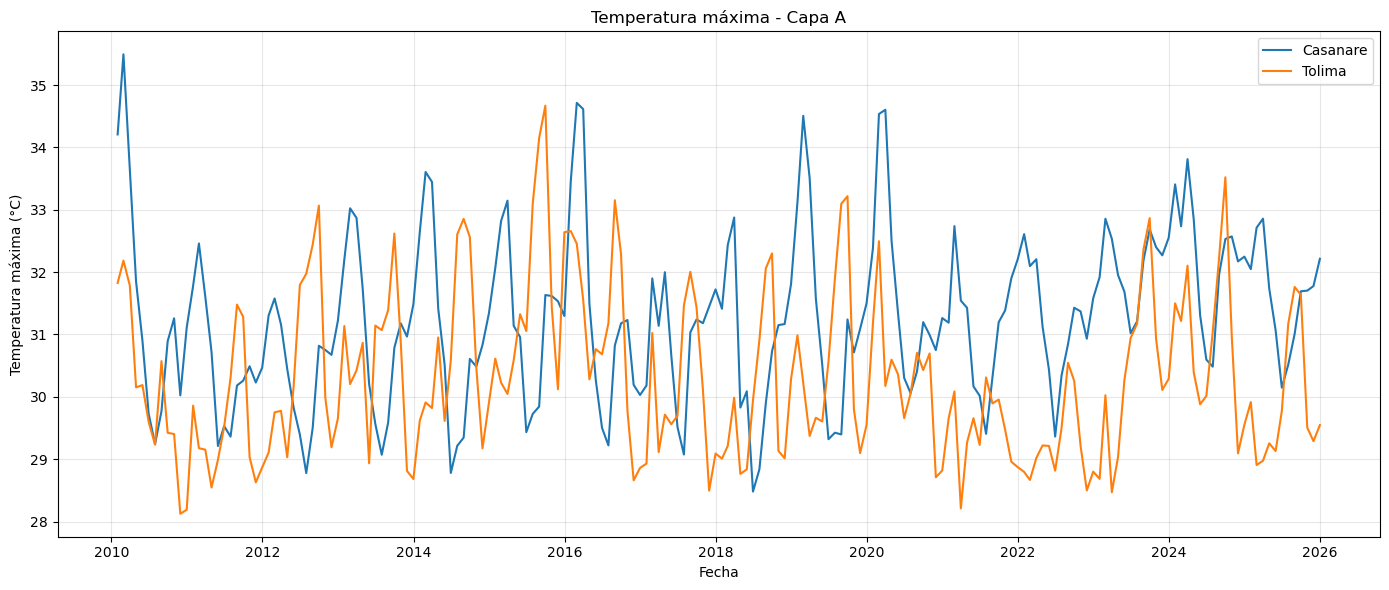

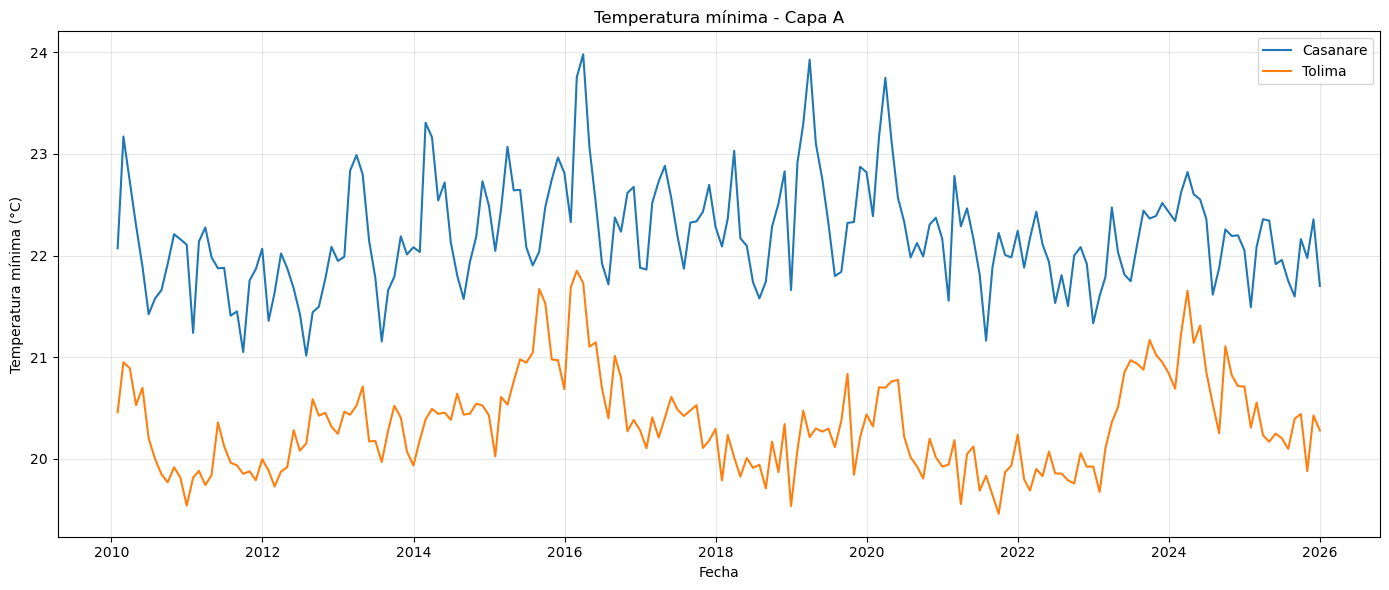

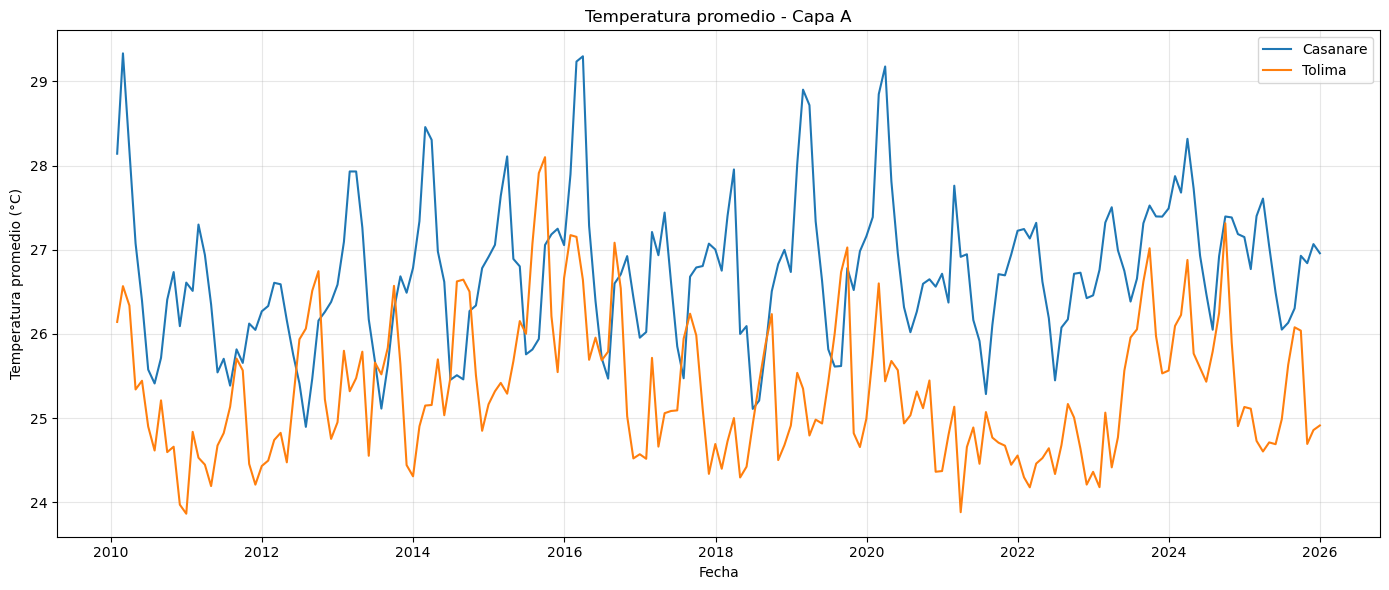

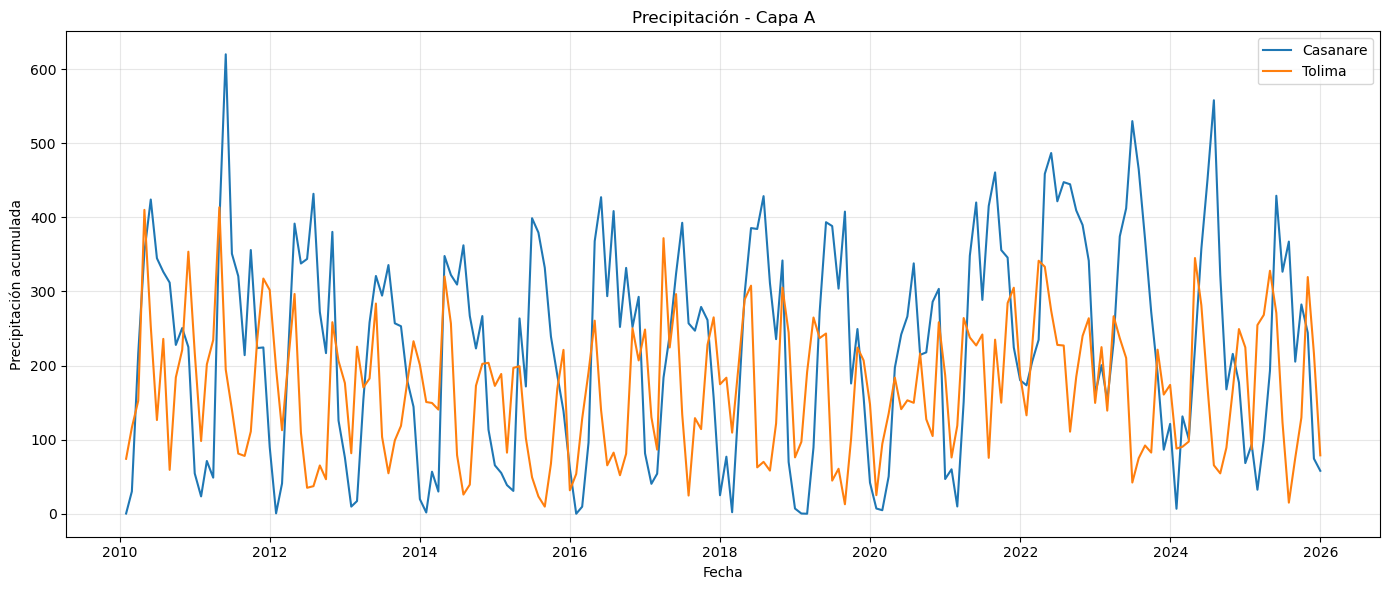

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar formato fecha
df_CapaA["date"] = pd.to_datetime(df_CapaA["date"])

# Agrupar por departamento y mes
clima_mensual = (
    df_CapaA
    .groupby(["department", pd.Grouper(key="date", freq="M")])
    .agg({
        "t_min": "mean",
        "t_mean": "mean",
        "t_max": "mean",
        "precip": "sum"
    })
    .reset_index()
)

# ==========================
# 1. Temperatura máxima
# ==========================
plt.figure(figsize=(14,6))

for depto in clima_mensual["department"].unique():
    datos = clima_mensual[
        clima_mensual["department"] == depto
    ]
    
    plt.plot(
        datos["date"],
        datos["t_max"],
        label=depto
    )

plt.title("Temperatura máxima - Capa A")
plt.xlabel("Fecha")
plt.ylabel("Temperatura máxima (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================
# 2. Temperatura mínima
# ==========================
plt.figure(figsize=(14,6))

for depto in clima_mensual["department"].unique():
    datos = clima_mensual[
        clima_mensual["department"] == depto
    ]
    
    plt.plot(
        datos["date"],
        datos["t_min"],
        label=depto
    )

plt.title("Temperatura mínima - Capa A")
plt.xlabel("Fecha")
plt.ylabel("Temperatura mínima (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================
# 3. Temperatura promedio
# ==========================
plt.figure(figsize=(14,6))

for depto in clima_mensual["department"].unique():
    datos = clima_mensual[
        clima_mensual["department"] == depto
    ]
    
    plt.plot(
        datos["date"],
        datos["t_mean"],
        label=depto
    )

plt.title("Temperatura promedio - Capa A")
plt.xlabel("Fecha")
plt.ylabel("Temperatura promedio (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================
# 4. Precipitación
# ==========================
plt.figure(figsize=(14,6))

for depto in clima_mensual["department"].unique():
    datos = clima_mensual[
        clima_mensual["department"] == depto
    ]
    
    plt.plot(
        datos["date"],
        datos["precip"],
        label=depto
    )

plt.title("Precipitación - Capa A")
plt.xlabel("Fecha")
plt.ylabel("Precipitación acumulada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Análisis descriptivo

In [ ]:
import pandas as pd

# Variables climáticas
variables = ["t_min", "t_mean", "t_max", "precip"]

# Estadísticas descriptivas por departamento
tabla_descriptiva = (
    df_CapaA
    .groupby("department")[variables]
    .describe()
)

# Redondear
tabla_descriptiva = tabla_descriptiva.round(2)

# Organizar nombres de columnas
tabla_descriptiva.columns = [
    "N",
    "Media",
    "Desv_Est",
    "Min",
    "P25",
    "Mediana",
    "P75",
    "Max"
] * len(variables)

# Mostrar completa
pd.set_option('display.max_columns', None)

print(tabla_descriptiva)

# Opcional: guardar a Excel
tabla_descriptiva.to_excel(
    "Descriptivos_CapaA.xlsx"
)

tabla_descriptiva

                 N  Media  Desv_Est    Min    P25  Mediana    P75    Max  \
department                                                                 
Casanare    5844.0  22.20      0.78  19.34  21.71    22.17  22.66  25.69   
Tolima      5844.0  20.34      0.68  17.72  19.87    20.30  20.77  23.04   

                 N  Media  Desv_Est    Min    P25  Mediana    P75    Max  \
department                                                                 
Casanare    5844.0  26.72      1.09  22.22  26.06    26.70  27.36  31.04   
Tolima      5844.0  25.32      1.11  21.81  24.53    25.23  26.06  29.55   

                 N  Media  Desv_Est    Min    P25  Mediana    P75    Max  \
department                                                                 
Casanare    5844.0  31.25      1.74  23.96  30.23    31.30  32.33  37.64   
Tolima      5844.0  30.31      1.87  24.17  29.00    30.18  31.59  36.69   

                 N  Media  Desv_Est  Min   P25  Mediana    P75    Max  
department   

,N,Media,Desv_Est,Min,P25,Mediana,P75,Max,N,Media,Desv_Est,Min,P25,Mediana,P75,Max,N,Media,Desv_Est,Min,P25,Mediana,P75,Max,N,Media,Desv_Est,Min,P25,Mediana,P75,Max
department,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Casanare,5844.0,22.20,0.78,19.34,21.71,22.17,22.66,25.69,5844.0,26.72,1.09,22.22,26.06,26.70,27.36,31.04,5844.0,31.25,1.74,23.96,30.23,31.30,32.33,37.64,5844.0,7.54,10.07,0.0,0.28,4.06,10.99,95.20
Tolima,5844.0,20.34,0.68,17.72,19.87,20.30,20.77,23.04,5844.0,25.32,1.11,21.81,24.53,25.23,26.06,29.55,5844.0,30.31,1.87,24.17,29.00,30.18,31.59,36.69,5844.0,5.55,7.39,0.0,0.40,2.62,7.76,55.94
